<a href="https://colab.research.google.com/github/lovnishverma/Python-Getting-Started/blob/main/Ridge_and_Lasso_212.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ridge and Lasso Regression
## A hands-on notebook for Regression Techniques

---

### Recap

1. **Linear Regression** — fit a straight line (or flat plane) through data.
2. **Polynomial Regression** — add $x^2, x^3, \dots$ as extra features so the line can bend.

That is genuinely all you need. Everything else is built up from scratch here.

### What you will be able to do by the end

- Explain **why** a perfectly fitted model can still be a bad model.
- Recognise the **fingerprint of overfitting** by looking at coefficients.
- Write down and explain the Ridge and Lasso loss functions.
- Say exactly what `alpha` does, and why bigger is **not** better.
- Explain why Lasso can delete features and Ridge cannot.
- Scale features correctly, and say why forgetting it ruins everything.
- Pick `alpha` honestly using cross-validation, without cheating on the test set.

### Notation used throughout

| Symbol | Means |
|---|---|
| $x_1, x_2, \dots, x_p$ | the input features (columns) |
| $y$ | the true answer we want to predict |
| $\hat{y}$ | the model's prediction |
| $\beta_1, \beta_2, \dots, \beta_p$ | the coefficients (weights) the model learns |
| $\beta_0$ | the intercept |
| $n$ | number of rows |
| $p$ | number of features |
| $\alpha$ | the regularization strength (we choose this, not the model) |

---
# Part 0 — Setup

Run this once. Everything below depends on it.

In [59]:
# Standard scientific Python stack
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# The models we will meet
from sklearn.linear_model import LinearRegression   # the one you already know
from sklearn.linear_model import Ridge, RidgeCV     # L2 regularization
from sklearn.linear_model import Lasso, LassoCV     # L1 regularization

# Supporting tools
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# Fix the random seed so YOUR numbers match the numbers described in the text
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Setup complete. Versions:")
import sklearn
print("  scikit-learn:", sklearn.__version__)
print("  numpy       :", np.__version__)
print("  pandas      :", pd.__version__)

Setup complete. Versions:
  scikit-learn: 1.6.1
  numpy       : 2.1.3
  pandas      : 2.2.3


In [60]:
# One consistent colour scheme for the whole notebook, so the plots are easy to read:
#   grey   = plain Linear Regression (no regularization)
#   blue   = Ridge
#   orange = Lasso
C_OLS   = "#444444"
C_RIDGE = "#1f6fb4"
C_LASSO = "#e8820c"
C_DATA  = "#8c8c8c"

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
})

def scores(y_true, y_pred):
    """Return the three regression scores we use everywhere in this notebook."""
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
    }

print("Plot style and helper function ready.")

Plot style and helper function ready.


> **IN PLAIN ENGLISH — the three scores**
>
> | Score | What it answers | Good value |
> |---|---|---|
> | **MAE** (Mean Absolute Error) | "On average, how far off am I?" — in the same units as $y$ | smaller |
> | **RMSE** (Root Mean Squared Error) | Same idea, but it punishes big mistakes harder | smaller |
> | **R2** (R-squared) | "What fraction of the variation did I explain?" | closer to 1 |
>
> R2 of 0 means the model is no better than always predicting the average.
> R2 can go **negative**, which means the model is worse than that. You will see this happen later.

---
# Part 1 — The problem you already have (you just haven't seen it yet)

Regularization is a **solution**. Before we look at any solution, we need to feel the **problem**.

The problem lives inside something you already know: polynomial regression.

## 1.1 A small, honest dataset

We make 24 data points. The true relationship is a gentle curve:

$$y = 0.5x^2 - x + 2 + \text{noise}$$

Real data always has noise — measurement error, randomness, things we didn't record.
Our job is to recover the **curve**, not to memorise the **noise**.

Training points: 16
Test points    : 8


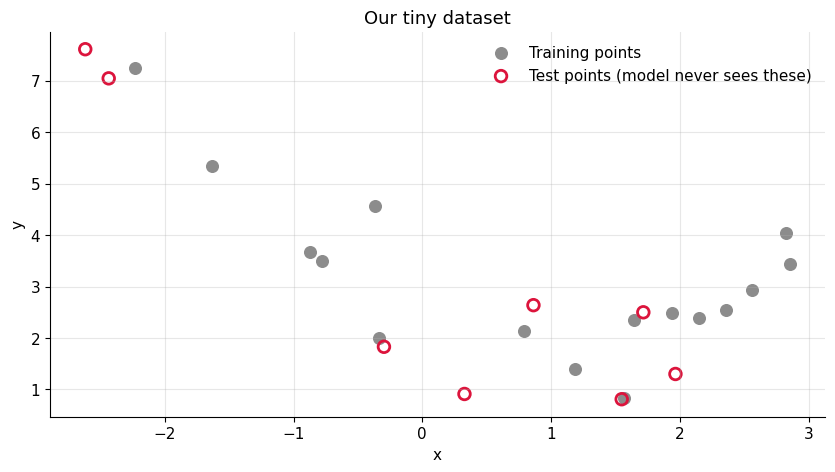

In [61]:
rng = np.random.default_rng(RANDOM_STATE)

n_points = 24
x = np.sort(rng.uniform(-3, 3, n_points))
y = 0.5 * x**2 - 1.0 * x + 2 + rng.normal(0, 1.0, n_points)   # the last term is the noise

X = x.reshape(-1, 1)          # scikit-learn always wants a 2-D array of features

# Hold out some points that the model is never allowed to see while training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

print(f"Training points: {len(X_train)}")
print(f"Test points    : {len(X_test)}")

plt.figure()
plt.scatter(X_train, y_train, s=70, color=C_DATA, label="Training points")
plt.scatter(X_test, y_test, s=70, facecolors="none", edgecolors="crimson",
            linewidths=2, label="Test points (model never sees these)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Our tiny dataset")
plt.legend()
plt.show()

## 1.2 Fit three polynomials: degree 1, degree 2, degree 12

This is exactly the polynomial regression you already know.
`PolynomialFeatures(degree=d)` takes the single column `x` and builds the columns
$x, x^2, x^3, \dots, x^d$. Then plain Linear Regression fits a coefficient to each one.

- **Degree 1** = a straight line (too simple for a curve)
- **Degree 2** = a parabola (this matches how the data was actually made)
- **Degree 12** = a very bendy curve with 12 coefficients to play with

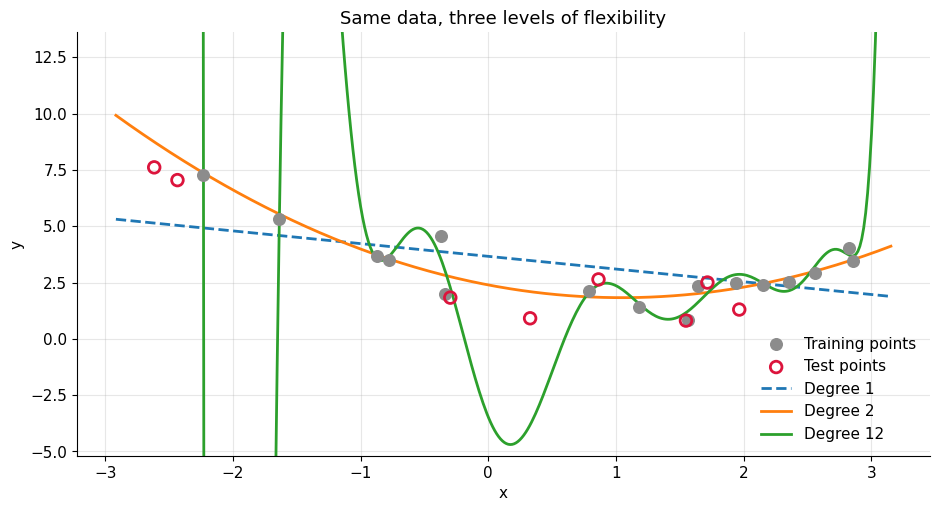

In [62]:
def poly_model(model, degree):
    """Polynomial features -> scaling -> the model. (Scaling is explained in Part 5.)"""
    return Pipeline([
        ("poly",  PolynomialFeatures(degree=degree, include_bias=False)),
        ("scale", StandardScaler()),
        ("model", model),
    ])

degrees = [1, 2, 12]
fitted = {}

for d in degrees:
    m = poly_model(LinearRegression(), d)
    m.fit(X_train, y_train)
    fitted[d] = m

# A dense grid of x values so we can draw smooth curves
x_grid = np.linspace(x.min() - 0.3, x.max() + 0.3, 400).reshape(-1, 1)

plt.figure(figsize=(11, 5.5))
plt.scatter(X_train, y_train, s=70, color=C_DATA, zorder=3, label="Training points")
plt.scatter(X_test, y_test, s=70, facecolors="none", edgecolors="crimson",
            linewidths=2, zorder=3, label="Test points")

for d, style in zip(degrees, ["--", "-", "-"]):
    plt.plot(x_grid, fitted[d].predict(x_grid), style, linewidth=2, label=f"Degree {d}")

plt.ylim(y.min() - 6, y.max() + 6)     # the degree-9 curve runs off the chart on purpose
plt.xlabel("x")
plt.ylabel("y")
plt.title("Same data, three levels of flexibility")
plt.legend()
plt.show()

> **CHECKPOINT**
>
> Look at the degree-12 curve. It passes very close to almost every **grey** training point —
> and then swings violently up or down, missing the **red** test points badly.
> Near the edges it shoots clean off the top or bottom of the chart.
>
> That is **overfitting**: the model has memorised the noise instead of learning the pattern.

## 1.3 Confirm it with numbers, not eyeballs

A model that has memorised the training data will look **brilliant on training data**
and **terrible on data it has never seen**. Let's check.

In [63]:
rows = []
for d in degrees:
    m = fitted[d]
    rows.append({
        "Degree": d,
        "Train R2": r2_score(y_train, m.predict(X_train)),
        "Test R2":  r2_score(y_test,  m.predict(X_test)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, m.predict(X_test))),
    })

display(pd.DataFrame(rows).round(3).set_index("Degree"))

,Train R2,Test R2,Test RMSE
Degree,,,
1,0.350,0.483,1.822
2,0.846,0.851,0.978
12,0.904,-2682634.142,4151.656


> **CHECKPOINT — read the table carefully**
>
> - Degree 1: mediocre on train, mediocre on test. This is **underfitting** — too rigid.
> - Degree 2: good on train, good on test. This is the **sweet spot**.
> - Degree 12: *best* train R2 of all three, and a catastrophic test RMSE (in the **thousands**).
>   Its test R2 is not just bad, it is a large negative number.
>
> **The most important sentence in this whole notebook:**
> a high training score is not evidence that a model is good.

## 1.4 The clue — where did the damage actually come from?

Here is the question that leads straight to Ridge and Lasso:

> The degree-12 model has the same data as the degree-2 model.
> What is it *doing differently* to produce those wild swings?

Let's just look at the **coefficients** it learned.

A **coefficient** is essentially a weight that controls how much a particular feature contributes to the prediction.

In [64]:
coef_2 = fitted[2].named_steps["model"].coef_
coef_big = fitted[12].named_steps["model"].coef_

def show_coefs(coefs):
    for i, c in enumerate(coefs, start=1):
        print(f"   {f'beta_{i} (x^{i})':<16} = {c:>18,.2f}")

print("Degree-2 coefficients:")
show_coefs(coef_2)

print("\nDegree-12 coefficients:")
show_coefs(coef_big)

print("\n" + "-" * 62)
print(f"Largest coefficient, degree  2 : {np.abs(coef_2).max():>20,.2f}")
print(f"Largest coefficient, degree 12 : {np.abs(coef_big).max():>20,.2f}")
print(f"Sum of squared coefficients, degree  2 : {np.sum(coef_2**2):>20,.2f}")
print(f"Sum of squared coefficients, degree 12 : {np.sum(coef_big**2):>20,.2f}")

Degree-2 coefficients:
   beta_1 (x^1)     =              -1.74
   beta_2 (x^2)     =               1.36

Degree-12 coefficients:
   beta_1 (x^1)     =             -22.11
   beta_2 (x^2)     =              91.38
   beta_3 (x^3)     =             333.20
   beta_4 (x^4)     =          -1,503.57
   beta_5 (x^5)     =          -1,574.19
   beta_6 (x^6)     =          10,282.95
   beta_7 (x^7)     =          -2,843.73
   beta_8 (x^8)     =         -25,469.39
   beta_9 (x^9)     =          24,181.78
   beta_10 (x^10)   =          14,311.67
   beta_11 (x^11)   =         -27,139.56
   beta_12 (x^12)   =           9,355.88

--------------------------------------------------------------
Largest coefficient, degree  2 :                 1.74
Largest coefficient, degree 12 :            27,139.56
Sum of squared coefficients, degree  2 :                 4.87
Sum of squared coefficients, degree 12 :     2,381,044,985.01


> **BIG IDEA — overfitting has a fingerprint**
>
> The degree-12 model's coefficients run into the **tens of thousands**, and the sum of their
> squares is in the **billions**. The degree-2 model's coefficients are close to 1.
>
> Why does that happen? To pass through every noisy point, the curve has to bend hard.
> Bending hard means one term pushes the curve up by an enormous amount and the next term
> yanks it back down by an almost equally enormous amount. The huge numbers nearly cancel —
> which works beautifully on the training points and falls apart everywhere else.
>
> A model held together by huge, nearly-cancelling coefficients is **fragile**:
> move the input slightly and the prediction jumps wildly.
>
> $$\boxed{\text{Overfitting} \;\longleftrightarrow\; \text{huge coefficients}}$$
>
> And that gives us something to attack. We cannot easily tell a model "don't overfit".
> But we *can* tell it **"keep your coefficients small"**.

> **TRY IT**
>
> Go back to the cell where `degrees` is defined and change it to `degrees = [1, 2, 16]`.
> Re-run that cell and the two cells after it. The coefficients get even larger and the test
> score gets even worse. **Then change it back to `[1, 2, 12]` before continuing**, because the
> rest of the notebook uses those three models.

---
# Part 2 — The fix, in a single line

Linear Regression has exactly one instruction:

$$\text{minimise} \quad \mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

In words: *"make the training errors as small as possible, by any means necessary."*

The phrase **"by any means necessary"** is the bug. Using coefficients of 4,000 is a
perfectly acceptable means, as far as that instruction is concerned.

So we change the instruction. We add a second term:

$$\boxed{\;\text{Loss} \;=\; \underbrace{\mathrm{MSE}}_{\text{fit the data}} \;+\; \alpha \times \underbrace{\text{Penalty}}_{\text{size of the coefficients}}\;}$$

Now the model has to satisfy **two** bosses at once:

| Term | What it wants | If it wins alone |
|---|---|---|
| MSE | fit every training point | overfitting |
| Penalty | keep all coefficients near zero | underfitting |
| $\alpha$ | decides who gets the louder voice | — |

> **THE ANALOGY**
>
> Think of coefficients as **money the model is allowed to spend**.
>
> Plain Linear Regression has an unlimited credit card: it will happily spend 4,000 units on
> $x^7$ if that shaves a tiny bit off the training error.
>
> Regularization puts a **price tag** on every unit spent. Now the model will only use a big
> coefficient if that coefficient genuinely earns its keep. Tiny improvements in training
> error are no longer worth the cost.

## 2.1 Let's actually compute it by hand

Forget scikit-learn for a moment. Suppose we have two candidate models and we must choose one.

- **Model S (simple):** small coefficients, fits the training data slightly worse.
- **Model W (wild):** huge coefficients, fits the training data slightly better.

We will compute `Loss = MSE + alpha * sum(beta^2)` for both, at different values of `alpha`,
and see which one the rule prefers.

In [65]:
# Made-up but realistic numbers
model_S = {"name": "Model S (simple)", "mse": 1.20, "betas": np.array([0.8, -0.5, 0.3])}
model_W = {"name": "Model W (wild)  ", "mse": 0.90, "betas": np.array([120.0, -260.0, 145.0])}

print("Model S coefficients:", model_S["betas"], " -> sum of squares =", f"{np.sum(model_S['betas']**2):,.2f}")
print("Model W coefficients:", model_W["betas"], " -> sum of squares =", f"{np.sum(model_W['betas']**2):,.2f}")
print()
print(f"{'alpha':>10} | {'Loss of S':>14} | {'Loss of W':>16} | winner")
print("-" * 64)

for alpha in [0.0, 0.0001, 0.001, 0.01, 1.0]:
    loss_S = model_S["mse"] + alpha * np.sum(model_S["betas"]**2)
    loss_W = model_W["mse"] + alpha * np.sum(model_W["betas"]**2)
    winner = "Model S" if loss_S < loss_W else "Model W"
    print(f"{alpha:>10} | {loss_S:>14,.4f} | {loss_W:>16,.4f} | {winner}")

Model S coefficients: [ 0.8 -0.5  0.3]  -> sum of squares = 0.98
Model W coefficients: [ 120. -260.  145.]  -> sum of squares = 103,025.00

     alpha |      Loss of S |        Loss of W | winner
----------------------------------------------------------------
       0.0 |         1.2000 |           0.9000 | Model W
    0.0001 |         1.2001 |          11.2025 | Model S
     0.001 |         1.2010 |         103.9250 | Model S
      0.01 |         1.2098 |       1,031.1500 | Model S
       1.0 |         2.1800 |     103,025.9000 | Model S


> **CHECKPOINT — this table is the entire idea of regularization**
>
> - At `alpha = 0` the penalty is switched off. The rule picks **Model W**, because W has the
>   lower training MSE. This is exactly what plain Linear Regression does.
> - As soon as `alpha` becomes even slightly positive, W's enormous coefficients start costing
>   it more than its small MSE advantage is worth, and the rule flips to **Model S**.
>
> Notice that nothing about the data changed. Only the *definition of "best"* changed.

## 2.2 What exactly is `alpha`?

`alpha` is a **hyperparameter**. That word has a precise meaning:

| | Chosen by | Example |
|---|---|---|
| **Parameter** | learned by the model from the data | the coefficients $\beta$ |
| **Hyperparameter** | chosen by **you**, before training | $\alpha$ |

The model can never learn `alpha` for itself. If it tried, it would pick `alpha = 0`,
because that always gives the lowest training error. That defeats the whole purpose.

| `alpha` | What happens |
|---|---|
| `0` | No penalty at all. **This is ordinary Linear Regression.** |
| small (e.g. 0.001) | Gentle nudge; coefficients shrink a little |
| moderate (e.g. 1 – 10) | Real constraint; coefficients clearly smaller |
| very large (e.g. 10000) | Coefficients crushed toward 0; model predicts nearly a flat line -> **underfitting** |

$$\boxed{\alpha \uparrow \;\Rightarrow\; \text{stronger penalty} \;\Rightarrow\; \text{smaller coefficients} \;\Rightarrow\; \text{simpler model}}$$

$$\boxed{\alpha = 0 \;\Rightarrow\; \text{plain Linear Regression}}$$

> **WATCH OUT — the single most common beginner mistake**
>
> Bigger `alpha` does **not** mean a better model. It means a **more constrained** model.
> There is a best value of `alpha` somewhere in the middle, and it is different for every
> dataset. Part 6 shows how to find it honestly.

## 2.3 Two ways to measure "size of the coefficients"

We said `Loss = MSE + alpha * Penalty`. We still have to decide what **Penalty** means.

There are two obvious choices, and they give the two methods in this notebook:

| Name | Penalty | Called | Nickname |
|---|---|---|---|
| **Ridge** | $\sum_{j=1}^{p} \beta_j^2$ | L2 penalty | "square them" |
| **Lasso** | $\sum_{j=1}^{p} \lvert \beta_j \rvert$ | L1 penalty | "absolute value them" |

They look almost identical. They behave very differently, and the difference matters a lot.
We take them one at a time.

*(Note: the intercept $\beta_0$ is never penalised. Penalising it would force predictions
toward zero rather than toward the average, which is not what we want. scikit-learn already
handles this for you.)*

---
# Part 3 — Ridge Regression (the L2 penalty)

$$\boxed{\;\text{Ridge Loss} \;=\; \mathrm{MSE} \;+\; \alpha \sum_{j=1}^{p} \beta_j^{2}\;}$$

**In plain English:** add up the *squares* of all the coefficients, multiply by `alpha`,
and add that to the error the model is trying to minimise.

Why squares? Because squaring punishes **large** coefficients far more than small ones:

- a coefficient of 2 costs $2^2 = 4$
- a coefficient of 20 costs $20^2 = 400$ — that is **100 times** the cost, for only 10 times the size

So Ridge hunts down the biggest coefficients first. Exactly what we want,
since Part 1 showed that huge coefficients are the fingerprint of overfitting.

Ridge regression is a technique for analyzing multiple regression data. When multicollinearity occurs, least squares estimates are unbiased. This is a regularized linear regression model, it tries to reduce the model complexity by adding a penalty term to the cost function. A degree of bias is added to the regression estimates, and as a result, ridge regression reduces the standard errors.

In [66]:
# See the "squares punish big values" effect for yourself
demo_betas = np.array([0.5, 2.0, 20.0])
print(f"{'coefficient':>12} | {'L2 cost (b^2)':>14}")
print("-" * 30)
for b in demo_betas:
    print(f"{b:>12.1f} | {b**2:>14.1f}")
print("-" * 30)
print(f"{'TOTAL':>12} | {np.sum(demo_betas**2):>14.1f}")
print("\nThe single coefficient of 20 contributes",
      f"{100*400/np.sum(demo_betas**2):.1f}% of the entire penalty.")

 coefficient |  L2 cost (b^2)
------------------------------
         0.5 |            0.2
         2.0 |            4.0
        20.0 |          400.0
------------------------------
       TOTAL |          404.2

The single coefficient of 20 contributes 98.9% of the entire penalty.


## 3.1 Ridge on our wild degree-12 model

Same data. Same degree-12 polynomial. Same features. **Only the loss function changes.**

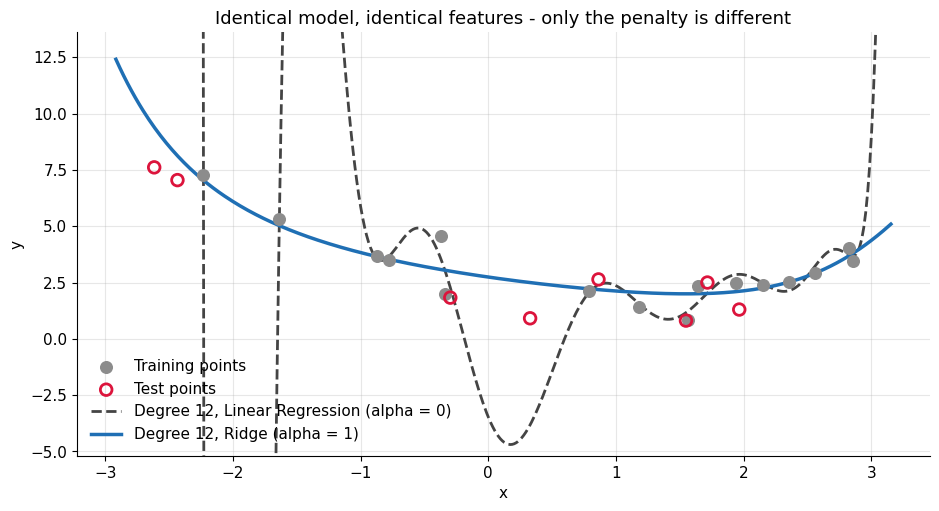

,MAE,RMSE,R2
Model,,,
"Degree 12, Linear Regression",1768.811,4151.656,-2682634.142
"Degree 12, Ridge (alpha=1)",1.070,1.160,0.791


In [67]:
ridge_big = poly_model(Ridge(alpha=1.0), degree=12)
ridge_big.fit(X_train, y_train)

ols_big = fitted[12]   # the plain Linear Regression version from Part 1

plt.figure(figsize=(11, 5.5))
plt.scatter(X_train, y_train, s=70, color=C_DATA, zorder=3, label="Training points")
plt.scatter(X_test, y_test, s=70, facecolors="none", edgecolors="crimson",
            linewidths=2, zorder=3, label="Test points")
plt.plot(x_grid, ols_big.predict(x_grid),   color=C_OLS,   linewidth=2, linestyle="--",
         label="Degree 12, Linear Regression (alpha = 0)")
plt.plot(x_grid, ridge_big.predict(x_grid), color=C_RIDGE, linewidth=2.5,
         label="Degree 12, Ridge (alpha = 1)")
plt.ylim(y.min() - 6, y.max() + 6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Identical model, identical features - only the penalty is different")
plt.legend()
plt.show()

comp = pd.DataFrame([
    {"Model": "Degree 12, Linear Regression", **scores(y_test, ols_big.predict(X_test))},
    {"Model": "Degree 12, Ridge (alpha=1)",   **scores(y_test, ridge_big.predict(X_test))},
]).set_index("Model")
display(comp.round(3))

> **CHECKPOINT**
>
> The blue Ridge curve is calm and sensible. It does **not** pass through every training point —
> and that is the point. It gave up a little training accuracy and bought back an enormous
> amount of test accuracy. Test RMSE drops from the thousands to roughly 1.2, and test R2 goes
> from about minus 2.7 million to about 0.79.
>
> This is called the **bias-variance trade-off**:
> we deliberately accepted a bit of *bias* (systematic error) to remove a huge amount of
> *variance* (sensitivity to noise).

## 3.2 Look at the coefficients again

Part 1 told us to watch the coefficients. So let's watch them.

In [68]:
coef_table = pd.DataFrame({
    "Term": [f"x^{i}" for i in range(1, 13)],
    "Linear Regression": ols_big.named_steps["model"].coef_,
    "Ridge (alpha=1)":   ridge_big.named_steps["model"].coef_,
}).set_index("Term")

display(coef_table.round(3))

print(f"Sum of squared coefficients, Linear Regression : {np.sum(ols_big.named_steps['model'].coef_**2):>20,.2f}")
print(f"Sum of squared coefficients, Ridge             : {np.sum(ridge_big.named_steps['model'].coef_**2):>20,.2f}")

,Linear Regression,Ridge (alpha=1)
Term,,
x^1,-22.111,-1.312
x^2,91.385,0.548
x^3,333.203,-0.338
x^4,-1503.575,0.520
x^5,-1574.186,-0.078
x^6,10282.955,0.327
x^7,-2843.731,-0.039
x^8,-25469.387,0.168
x^9,24181.781,-0.054


Sum of squared coefficients, Linear Regression :     2,381,044,985.01
Sum of squared coefficients, Ridge             :                 2.56


> **CHECKPOINT**
>
> Coefficients in the tens of thousands became coefficients around 1.
> The sum of squares went from over **2 billion** down to under **3**.
> Ridge did not delete any term — every row still has a non-zero number in it —
> it simply **shrank them all**. Remember that; it is the key difference from Lasso.

## 3.3 Turning the alpha knob

`alpha` is a dial. Let's turn it from "off" all the way to "far too strong" and watch
what the curve does.

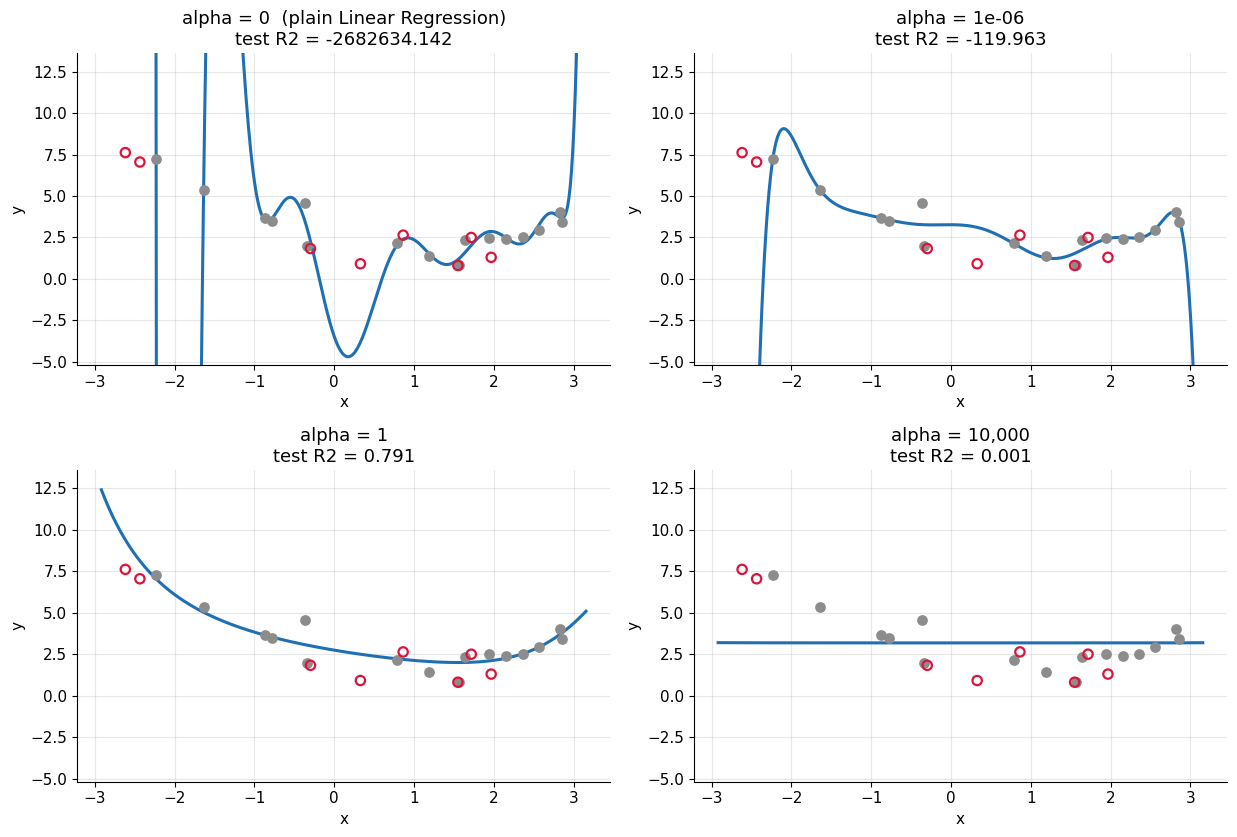

In [93]:
alpha_values = [0, 1e-6, 1, 10000]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 8.5))

for ax, a in zip(axes.ravel(), alpha_values):
    model = poly_model(LinearRegression() if a == 0 else Ridge(alpha=a), degree=12)
    model.fit(X_train, y_train)

    ax.scatter(X_train, y_train, s=45, color=C_DATA, zorder=3)
    ax.scatter(X_test, y_test, s=45, facecolors="none", edgecolors="crimson",
               linewidths=1.6, zorder=3)
    ax.plot(x_grid, model.predict(x_grid), color=C_RIDGE, linewidth=2.2)
    ax.set_ylim(y.min() - 6, y.max() + 6)

    test_r2 = r2_score(y_test, model.predict(X_test))
    label = "alpha = 0  (plain Linear Regression)" if a == 0 else f"alpha = {a:,g}"
    ax.set_title(f"{label}\ntest R2 = {test_r2:.3f}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.tight_layout()
plt.show()

> **CHECKPOINT — read the four panels left to right, top to bottom**
>
> | Panel | What you see | Name for it |
> |---|---|---|
> | `alpha = 0` | wild, off-the-chart swings | **overfitting** |
> | `alpha = 0.000001` | still wildly wiggly, penalty far too weak to matter | still overfitting |
> | `alpha = 1` | smooth curve that follows the real trend | **just right** |
> | `alpha = 10000` | almost a flat line, ignores the data entirely | **underfitting** |
>
> So `alpha` is not a "better model" dial. It is a **flexibility** dial, and you can turn it
> too far in either direction. Both ends are bad.

> **TRY IT**
>
> Change `alpha_values` to `[0, 0.01, 5, 100]` and re-run. Where does the curve start to look
> too flat? That boundary is different for every dataset — which is why Part 6 exists.

## 3.4 The coefficient path — the single most useful Ridge plot

Instead of four snapshots, let's sweep `alpha` continuously and draw **every coefficient**
as it shrinks. This picture is called the **regularization path**.

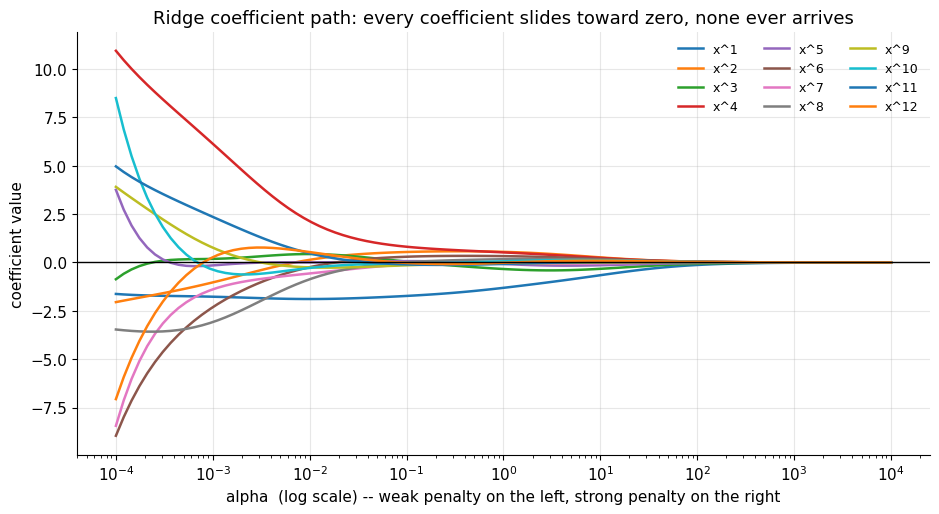

In [70]:
path_alphas = np.logspace(-4, 4, 100)
path_coefs = []

for a in path_alphas:
    m = poly_model(Ridge(alpha=a), degree=12)
    m.fit(X_train, y_train)
    path_coefs.append(m.named_steps["model"].coef_)

path_coefs = np.array(path_coefs)

plt.figure(figsize=(11, 5.5))
for j in range(path_coefs.shape[1]):
    plt.plot(path_alphas, path_coefs[:, j], linewidth=1.8, label=f"x^{j+1}")

plt.xscale("log")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("alpha  (log scale) -- weak penalty on the left, strong penalty on the right")
plt.ylabel("coefficient value")
plt.title("Ridge coefficient path: every coefficient slides toward zero, none ever arrives")
plt.legend(ncol=3, fontsize=9)
plt.show()

> **HOW TO READ A PATH PLOT** (you will see these everywhere in ML)
>
> - The **x-axis** is `alpha`, on a log scale. Left = almost no penalty. Right = huge penalty.
> - Each **coloured line** is one coefficient.
> - On the far **left**, the lines are spread far apart — those are the huge, unstable
>   Linear Regression coefficients.
> - Moving **right**, every line is squeezed toward the horizontal zero line.
> - On the far **right**, everything is essentially zero: the model has been flattened.
>
> **The Ridge signature:** the lines *approach* zero but never actually touch it.
> Every feature survives, just quieter. Hold on to that image — Lasso's version looks different.

---
# Part 4 — Lasso Regression (the L1 penalty)

$$\boxed{\;\text{Lasso Loss} \;=\; \mathrm{MSE} \;+\; \alpha \sum_{j=1}^{p} \lvert \beta_j \rvert\;}$$

One character changed: $\beta_j^2$ became $\lvert \beta_j \rvert$.

That tiny change gives Lasso a power Ridge does not have:
**Lasso can set coefficients to exactly zero.**

A coefficient of exactly zero means that feature contributes literally nothing —
it has been **removed from the equation**. So Lasso doesn't just shrink a model,
it *selects features*. That is why "Lasso" is shorthand for **automatic feature selection**.

*(The name is an acronym: **L**east **A**bsolute **S**hrinkage **a**nd **S**election **O**perator.
"Shrinkage AND Selection" — the name literally tells you what it does.)*

In [71]:
lasso_big = poly_model(Lasso(alpha=0.1, max_iter=100000), degree=12)
lasso_big.fit(X_train, y_train)

lasso_coefs = lasso_big.named_steps["model"].coef_

lasso_table = pd.DataFrame({
    "Term": [f"x^{i}" for i in range(1, 13)],
    "Ridge (alpha=1)": ridge_big.named_steps["model"].coef_,
    "Lasso (alpha=0.1)": lasso_coefs,
    "Lasso kept it?": np.where(np.isclose(lasso_coefs, 0.0), "REMOVED", "kept"),
}).set_index("Term")

display(lasso_table.round(4))

print(f"Ridge : {np.count_nonzero(ridge_big.named_steps['model'].coef_)} of 12 terms are non-zero")
print(f"Lasso : {np.count_nonzero(lasso_coefs)} of 12 terms are non-zero")
print()
print("Test RMSE, Ridge:", round(np.sqrt(mean_squared_error(y_test, ridge_big.predict(X_test))), 3))
print("Test RMSE, Lasso:", round(np.sqrt(mean_squared_error(y_test, lasso_big.predict(X_test))), 3))

,Ridge (alpha=1),Lasso (alpha=0.1),Lasso kept it?
Term,,,
x^1,-1.3115,-1.4978,kept
x^2,0.5483,0.6229,kept
x^3,-0.3383,-0.0000,REMOVED
x^4,0.5201,0.5155,kept
x^5,-0.0778,0.0000,REMOVED
x^6,0.3270,0.0000,REMOVED
x^7,-0.0394,0.0000,REMOVED
x^8,0.1678,0.0000,REMOVED
x^9,-0.0539,0.0000,REMOVED


Ridge : 12 of 12 terms are non-zero
Lasso : 3 of 12 terms are non-zero

Test RMSE, Ridge: 1.16
Test RMSE, Lasso: 0.926


> **CHECKPOINT**
>
> Look at the "Lasso kept it?" column. Most of the twelve polynomial terms say **REMOVED** —
> their coefficients are not "small", they are **exactly 0.0000**. Ridge's column has no zeros anywhere.
>
> Lasso worked out on its own that the data needs only a handful of terms and threw the rest away.
> Recall how we built the data: $y = 0.5x^2 - x + 2$. It really *is* a low-degree relationship,
> and Lasso rediscovered that from the data alone: the terms it kept are the low-degree ones,
> including the $x$ and $x^2$ that really are in the data. Notice that it also beat Ridge on
> test RMSE here.

## 4.1 Why can Lasso hit exactly zero when Ridge cannot?

This confuses almost everyone the first time. Here is the intuition that actually sticks.

Think about how hard the penalty **pulls** a coefficient toward zero. In calculus terms
that pull is the slope (derivative) of the penalty:

| Penalty | Formula | Slope (the pull toward zero) |
|---|---|---|
| Ridge (L2) | $\beta^2$ | $2\beta$ — **shrinks as $\beta$ shrinks** |
| Lasso (L1) | $\lvert\beta\rvert$ | $\pm 1$ — **constant, no matter how small $\beta$ gets** |

Read those two right-hand cells again, because that is the whole answer:

- **Ridge**: when $\beta = 10$ the pull is 20. When $\beta = 0.001$ the pull is 0.002.
  The closer the coefficient gets to zero, the *weaker* the force pushing it there.
  It is like walking half the remaining distance to a wall each step — you get very close,
  and you never arrive.

- **Lasso**: when $\beta = 10$ the pull is 1. When $\beta = 0.001$ the pull is *still* 1.
  The force never lets up. So if a feature isn't earning at least that much,
  Lasso shoves it all the way to zero and leaves it there.

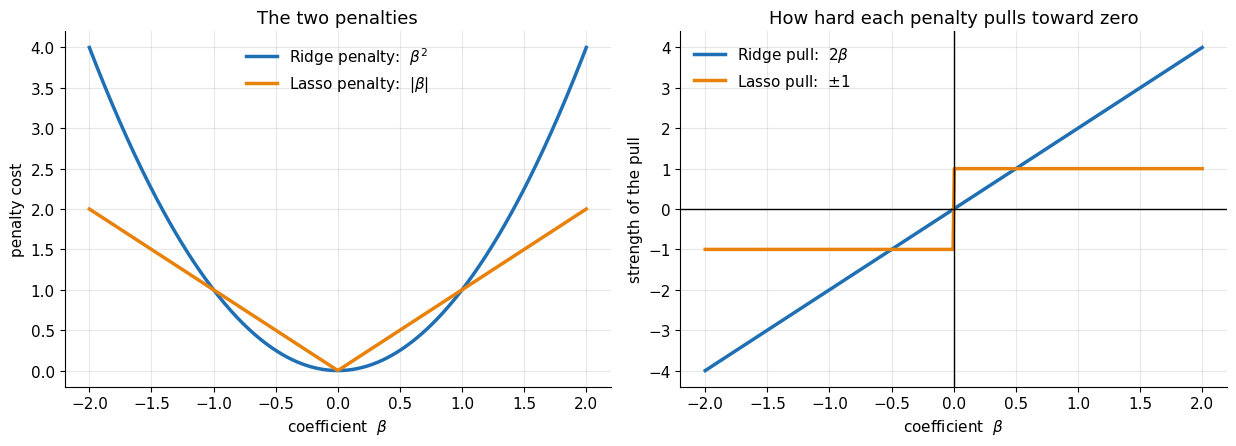

Right-hand plot: near beta = 0 the blue Ridge line passes through zero -- the pull dies out.
The orange Lasso line jumps straight from -1 to +1 -- the pull is full strength right up
to the edge, which is exactly what lets it push a coefficient onto zero and keep it there.


In [72]:
b = np.linspace(-2, 2, 400)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].plot(b, b**2,      color=C_RIDGE, linewidth=2.5, label="Ridge penalty:  $\\beta^2$")
axes[0].plot(b, np.abs(b), color=C_LASSO, linewidth=2.5, label="Lasso penalty:  $|\\beta|$")
axes[0].set_title("The two penalties")
axes[0].set_xlabel("coefficient  $\\beta$")
axes[0].set_ylabel("penalty cost")
axes[0].legend()

axes[1].plot(b, 2 * b, color=C_RIDGE, linewidth=2.5, label="Ridge pull:  $2\\beta$")
axes[1].plot(b, np.sign(b), color=C_LASSO, linewidth=2.5, label="Lasso pull:  $\\pm 1$")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("How hard each penalty pulls toward zero")
axes[1].set_xlabel("coefficient  $\\beta$")
axes[1].set_ylabel("strength of the pull")
axes[1].legend()

plt.tight_layout()
plt.show()

print("Right-hand plot: near beta = 0 the blue Ridge line passes through zero -- the pull dies out.")
print("The orange Lasso line jumps straight from -1 to +1 -- the pull is full strength right up")
print("to the edge, which is exactly what lets it push a coefficient onto zero and keep it there.")

## 4.2 The picture your textbook shows (circle vs diamond)

You will meet this diagram in every textbook, so here it is with an explanation.

Another way to write the same idea: *minimise MSE, subject to a budget on coefficient size.*

- Ridge's budget region, $\beta_1^2 + \beta_2^2 \le t$, is a **circle** — smooth all the way round.
- Lasso's budget region, $\lvert\beta_1\rvert + \lvert\beta_2\rvert \le t$, is a **diamond** — it has sharp **corners**, and each corner sits exactly on an axis.

The solution lands where the MSE contours first touch the budget region.
A smooth circle is most likely to be touched on a curved part (both coefficients non-zero).
A diamond is very likely to be touched **at a corner** — and a corner means one coefficient is exactly 0.

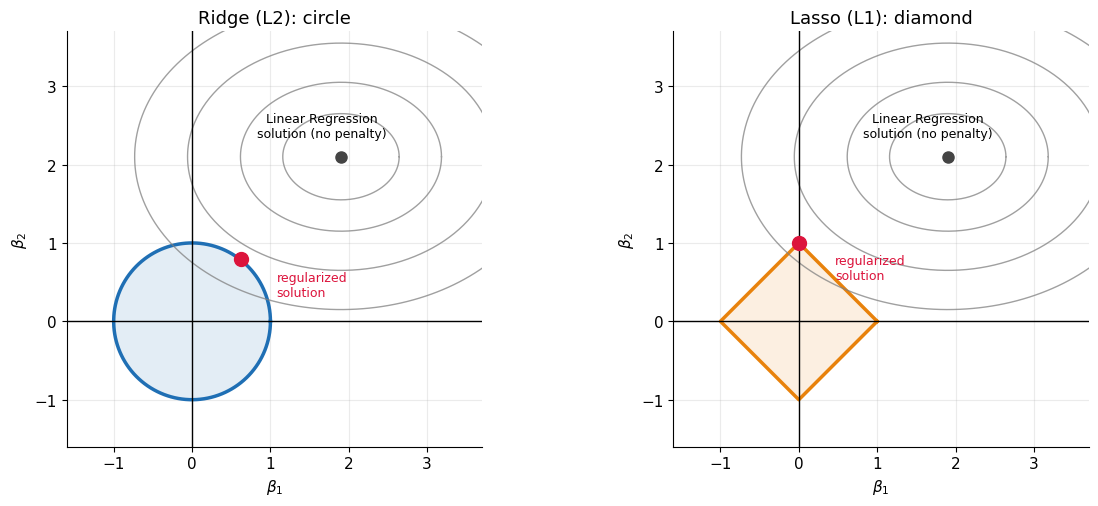

On the right, the red dot sits exactly on the vertical axis: beta_1 = 0, feature 1 deleted.
On the left, the red dot is off both axes: both coefficients are small but alive.


In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
theta = np.linspace(0, 2*np.pi, 400)

for ax, kind in zip(axes, ["Ridge (L2): circle", "Lasso (L1): diamond"]):
    if "Ridge" in kind:
        ax.plot(np.cos(theta), np.sin(theta), color=C_RIDGE, linewidth=2.5)
        ax.fill(np.cos(theta), np.sin(theta), color=C_RIDGE, alpha=0.12)
        touch = (0.62, 0.79)
    else:
        dx = [1, 0, -1, 0, 1]; dy = [0, 1, 0, -1, 0]
        ax.plot(dx, dy, color=C_LASSO, linewidth=2.5)
        ax.fill(dx, dy, color=C_LASSO, alpha=0.12)
        touch = (0.0, 1.0)              # a corner: beta_1 is exactly zero

    # MSE contours: ellipses centred on the unregularized (Linear Regression) solution
    cx, cy = 1.9, 2.1
    for r in [0.55, 0.95, 1.45, 1.95]:
        ax.plot(cx + r*1.35*np.cos(theta), cy + r*np.sin(theta),
                color="grey", linewidth=1, alpha=0.75)
    ax.plot(cx, cy, "o", color=C_OLS, markersize=8)
    ax.annotate("Linear Regression\nsolution (no penalty)", (cx, cy),
                textcoords="offset points", xytext=(-14, 14), fontsize=9, ha="center")
    ax.plot(*touch, "o", color="crimson", markersize=10, zorder=5)
    ax.annotate("regularized\nsolution", touch, textcoords="offset points",
                xytext=(26, -26), fontsize=9, color="crimson")

    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlim(-1.6, 3.7); ax.set_ylim(-1.6, 3.7)
    ax.set_aspect("equal")
    ax.set_xlabel("$\\beta_1$"); ax.set_ylabel("$\\beta_2$")
    ax.set_title(kind)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("On the right, the red dot sits exactly on the vertical axis: beta_1 = 0, feature 1 deleted.")
print("On the left, the red dot is off both axes: both coefficients are small but alive.")

## 4.3 The Lasso coefficient path — watch features disappear

Same sweep as before, but with Lasso. Compare this plot to the Ridge path in Part 3.4.

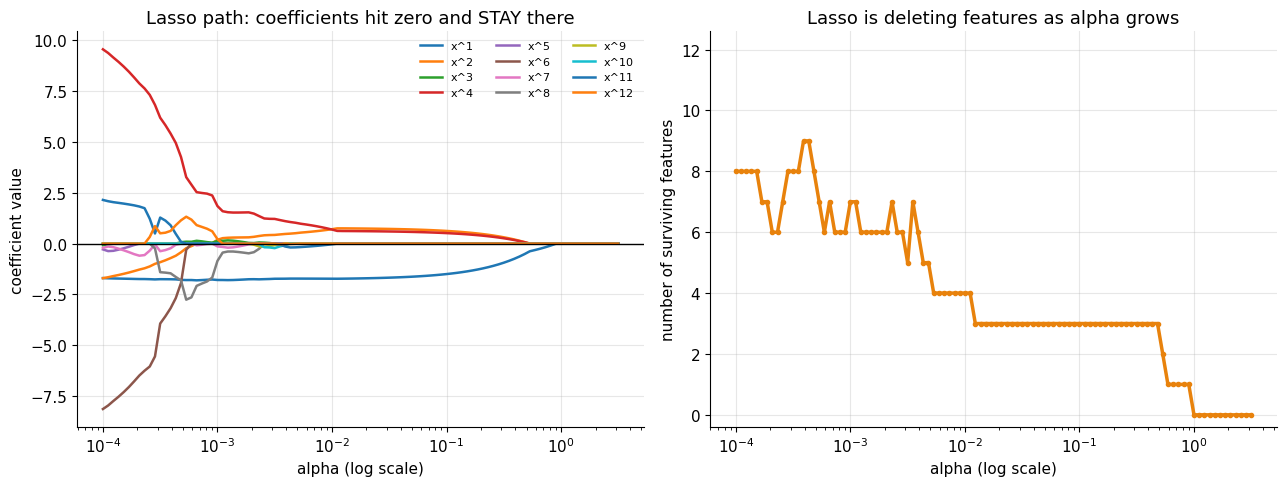

In [74]:
lasso_path_alphas = np.logspace(-4, 0.5, 100)
lasso_path_coefs, n_alive = [], []

for a in lasso_path_alphas:
    m = poly_model(Lasso(alpha=a, max_iter=100000), degree=12)
    m.fit(X_train, y_train)
    c = m.named_steps["model"].coef_
    lasso_path_coefs.append(c)
    n_alive.append(np.count_nonzero(c))

lasso_path_coefs = np.array(lasso_path_coefs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for j in range(lasso_path_coefs.shape[1]):
    axes[0].plot(lasso_path_alphas, lasso_path_coefs[:, j], linewidth=1.8, label=f"x^{j+1}")
axes[0].set_xscale("log")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("coefficient value")
axes[0].set_title("Lasso path: coefficients hit zero and STAY there")
axes[0].legend(ncol=3, fontsize=8)

axes[1].plot(lasso_path_alphas, n_alive, color=C_LASSO, linewidth=2.5, marker="o", markersize=3)
axes[1].set_xscale("log")
axes[1].set_ylim(-0.4, 12.6)
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("number of surviving features")
axes[1].set_title("Lasso is deleting features as alpha grows")

plt.tight_layout()
plt.show()

> **CHECKPOINT — put the two path plots side by side in your head**
>
> | | Ridge path | Lasso path |
> |---|---|---|
> | Lines approach zero | yes | yes |
> | Lines **reach** zero | never | yes, one by one |
> | Features at large alpha | all 12, all tiny | only a handful, rest deleted |
> | Right-hand plot | would be a flat line at 12 | a staircase going down |
>
> **One-line summary to memorise:**
>
> $$\boxed{\textbf{Ridge shrinks. Lasso shrinks and selects.}}$$

## 4.4 Ridge vs Lasso — the comparison table

| Property | **Ridge** | **Lasso** |
|---|---|---|
| Penalty | $\alpha \sum \beta_j^2$ | $\alpha \sum \lvert\beta_j\rvert$ |
| Common name | L2 | L1 |
| Shrinks coefficients | Yes | Yes |
| Produces exact zeros | No | **Yes** |
| Does feature selection | No | **Yes** |
| Keeps all features | Yes | No |
| With correlated features | splits the weight **between** them | usually keeps **one**, zeroes the others |
| Has a closed-form solution | Yes | No (solved iteratively) |
| Best when | many features all matter a bit | few features matter, many are junk |
| scikit-learn class | `Ridge` | `Lasso` |

> **WATCH OUT**
>
> When two features are strongly correlated (say "area in sq ft" and "number of rooms"),
> Lasso will often keep one and zero the other — and which one it keeps can flip if you
> change the data slightly. So a Lasso zero means *"not needed given the others"*,
> **not** *"this feature is unimportant in the real world"*. Do not report it as the latter.
>
> *(There is a third method, **Elastic Net**, that uses both penalties at once and handles
> correlated features better. It is `ElasticNet` in scikit-learn. That is a topic for another day.)*

---
# Part 5 — Scaling: the step everyone forgets, and the one that breaks everything

This part is short, but skipping it will silently ruin your results.

Here is the problem in one sentence:

> **Regularization penalises the *size* of a coefficient — but the size of a coefficient
> depends on the *units* of the feature.**

Plain Linear Regression does not care about units at all. Change a column from kilometres
to metres and the coefficient just divides by 1000; the predictions are identical.

Ridge and Lasso **do** care, because a coefficient of 50,000 costs a fortune under the
penalty while a coefficient of 0.05 is basically free — even when they describe the same
physical relationship.

## 5.1 A demonstration that should worry you

We build one dataset about house prices, with two features:

- `area` — floor area
- `distance` — distance from the city centre, in km

Then we make a **second copy where the only change is the unit of the area column**:
square metres becomes square kilometres. Same houses. Same prices. Same information.
Only the label on the ruler changed.

In [75]:
rng2 = np.random.default_rng(0)
n_houses = 300

area_m2 = rng2.uniform(50, 250, n_houses)      # 50 to 250 square metres
dist_km = rng2.uniform(1, 30, n_houses)        # 1 to 30 km from the centre
price   = 0.05 * area_m2 - 0.15 * dist_km + 5 + rng2.normal(0, 0.4, n_houses)

version_A = pd.DataFrame({"area_m2":  area_m2,        "distance_km": dist_km})   # sensible units
version_B = pd.DataFrame({"area_km2": area_m2 / 1e6,  "distance_km": dist_km})   # silly units

print("Version A (area in square metres):")
display(version_A.head(3).round(4))
print("Version B (area in square kilometres -- IDENTICAL DATA, different unit):")
display(version_B.head(3).round(8))

Version A (area in square metres):


,area_m2,distance_km
0,177.3923,27.0072
1,103.9573,17.9163
2,58.1947,2.1663


Version B (area in square kilometres -- IDENTICAL DATA, different unit):


,area_km2,distance_km
0,0.000177,27.007236
1,0.000104,17.916281
2,0.000058,2.166328


In [76]:
print("Plain Linear Regression -- does the unit matter?\n")
for name, D in [("A: area in m2 ", version_A), ("B: area in km2", version_B)]:
    lin = LinearRegression().fit(D, price)
    print(f"  {name}  R2 = {r2_score(price, lin.predict(D)):.4f}   coefficients = {np.round(lin.coef_, 6)}")

print("\n" + "=" * 70)
print("\nRidge with alpha = 10 -- does the unit matter now?\n")
for name, D in [("A: area in m2 ", version_A), ("B: area in km2", version_B)]:
    r = Ridge(alpha=10.0).fit(D, price)
    print(f"  {name}  R2 = {r2_score(price, r.predict(D)):.4f}   coefficients = {np.round(r.coef_, 6)}")

Plain Linear Regression -- does the unit matter?

  A: area in m2   R2 = 0.9869   coefficients = [ 0.050314 -0.155391]
  B: area in km2  R2 = 0.9869   coefficients = [ 5.03144036e+04 -1.55391000e-01]


Ridge with alpha = 10 -- does the unit matter now?

  A: area in m2   R2 = 0.9869   coefficients = [ 0.050314 -0.155309]
  B: area in km2  R2 = 0.1284   coefficients = [ 0.005342 -0.145589]


> **CHECKPOINT — this should alarm you**
>
> - Linear Regression: R2 is **identical** for both versions. Units are irrelevant to it.
> - Ridge: version A scores about **0.99**, version B scores about **0.13**. The model fell apart.
>
> Nothing about the houses changed. We relabelled one column and the model collapsed.
>
> **Why?** In version B, `area_km2` values are around 0.0001. To have any effect on the price,
> its coefficient would have to be around **50,000**. Under the L2 penalty that coefficient costs
> $50000^2 = 2.5$ billion. Ridge refuses to pay, crushes the coefficient to nearly zero,
> and throws away the most important feature in the dataset.
>
> $$\boxed{\text{Unscaled features} \;\Rightarrow\; \text{the penalty is applied unfairly}}$$

## 5.2 The fix: `StandardScaler`

Put every feature on the same footing before the penalty is applied. The standard way is the
**z-score**: subtract the mean, divide by the standard deviation.

$$x_{\text{scaled}} = \frac{x - \text{mean}(x)}{\text{std}(x)}$$

After this, **every** column has mean 0 and standard deviation 1. "One unit" now means
"one standard deviation" for every feature, so the penalty treats them all equally,
and coefficients become directly comparable to each other.

In [77]:
print("Ridge with alpha = 10, but with StandardScaler applied first:\n")
for name, D in [("A: area in m2 ", version_A), ("B: area in km2", version_B)]:
    pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=10.0))])
    pipe.fit(D, price)
    print(f"  {name}  R2 = {r2_score(price, pipe.predict(D)):.4f}"
          f"   coefficients = {np.round(pipe.named_steps['ridge'].coef_, 4)}")

print("\nIdentical R2. Identical coefficients. The unit problem is completely gone.")

Ridge with alpha = 10, but with StandardScaler applied first:

  A: area in m2   R2 = 0.9859   coefficients = [ 2.8967 -1.1924]
  B: area in km2  R2 = 0.9859   coefficients = [ 2.8967 -1.1924]

Identical R2. Identical coefficients. The unit problem is completely gone.


## 5.3 `Pipeline`, and the mistake it protects you from

You may be tempted to scale everything first and then split:

```python
X_scaled = StandardScaler().fit_transform(X)          # <-- WRONG
X_train, X_test = train_test_split(X_scaled, ...)
```

This is **data leakage**, and it is one of the most common bugs in applied ML.

> **THE ANALOGY**
>
> The test set is supposed to be a **final exam**: questions the model has genuinely never seen.
>
> `StandardScaler` computes a mean and a standard deviation. If you compute them over the whole
> dataset, those numbers contain information from the test rows. You have let the model peek at
> the exam paper while revising. Your test score is then flattering and meaningless.

The correct order is always:

$$\text{split first} \;\rightarrow\; \text{fit the scaler on TRAIN only} \;\rightarrow\; \text{apply it to train and test} \;\rightarrow\; \text{fit the model}$$

Doing that by hand is fiddly and easy to get wrong, especially inside cross-validation.
`Pipeline` does it correctly for you, automatically, every time:

In [78]:
# THE PATTERN. Use this for every regularized model you ever build.
model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])

# When you call .fit(), the Pipeline:
#   1. fits the scaler on X_train only, and transforms X_train
#   2. fits Ridge on the transformed X_train
# When you call .predict(X_test), it:
#   3. transforms X_test using the mean/std LEARNED FROM TRAIN
#   4. asks Ridge for predictions
#
# Inside cross-validation it repeats this correctly for every single fold.
# You cannot leak by accident.

print("Steps in this pipeline:", [name for name, _ in model.steps])
print("\nTo reach the model inside the pipeline:  model.named_steps['ridge']")

Steps in this pipeline: ['scaler', 'ridge']

To reach the model inside the pipeline:  model.named_steps['ridge']


> **RULE — no exceptions**
>
> Always wrap Ridge and Lasso in a `Pipeline` with a scaler. Always.
> It costs one extra line and removes two entire categories of bug.

---
# Part 6 — Choosing `alpha` honestly

We now know `alpha` matters enormously and that there is a sweet spot in the middle.
So how do we find it?

**Not** like this:

```python
for alpha in [...]:
    fit on train
    score on TEST                 # <-- WRONG
pick the alpha with the best TEST score
```

That is cheating, and the reason is worth understanding properly.

## 6.1 Homework, practice tests, and the final exam

| Split | Role | Analogy |
|---|---|---|
| **Training set** | the model learns its coefficients here | homework you study from |
| **Validation set** | you compare different `alpha` values here | practice tests |
| **Test set** | used exactly once, at the very end | the final exam |

If you try 60 values of `alpha` and keep whichever scores best on the **test** set, you have
turned the final exam into a practice test. The reported score is then optimistic —
you tuned until you matched that particular set of questions. Your model will disappoint
on genuinely new data.

> $$\boxed{\text{The test set is touched ONCE, at the very end, and never again.}}$$

## 6.2 K-fold cross-validation

Carving out a separate validation set wastes data, and one random split can be unlucky.
**K-fold cross-validation** solves both problems.

Split the *training* data into K equal parts ("folds"). Then, K times over:
train on K-1 folds, score on the held-out fold. Average the K scores.

Every training row gets used for training *and* for validating — just never at the same time.
And the test set is never involved at all.

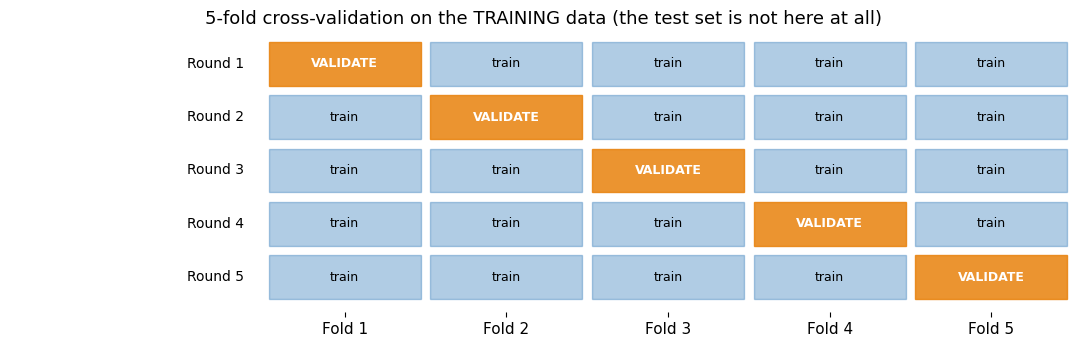

In [79]:
# A picture of what 5-fold cross-validation actually does
K = 5
fig, ax = plt.subplots(figsize=(11, 3.6))

for i in range(K):
    for j in range(K):
        is_val = (i == j)
        ax.add_patch(plt.Rectangle((j, K - 1 - i), 0.94, 0.82,
                                   color=C_LASSO if is_val else C_RIDGE,
                                   alpha=0.85 if is_val else 0.35))
        ax.text(j + 0.47, K - 1 - i + 0.41, "VALIDATE" if is_val else "train",
                ha="center", va="center", fontsize=9,
                color="white" if is_val else "black",
                fontweight="bold" if is_val else "normal")
    ax.text(-0.15, K - 1 - i + 0.41, f"Round {i+1}", ha="right", va="center", fontsize=10)

ax.set_xlim(-1.6, K); ax.set_ylim(-0.25, K)
ax.set_xticks([j + 0.47 for j in range(K)])
ax.set_xticklabels([f"Fold {j+1}" for j in range(K)])
ax.set_yticks([])
ax.grid(False)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("5-fold cross-validation on the TRAINING data (the test set is not here at all)")
plt.tight_layout()
plt.show()

## 6.3 The validation curve — find the sweet spot with your own eyes

Let's score many values of `alpha` by cross-validation **on the training set only**,
and plot the result. This is the honest version of the alpha sweep.

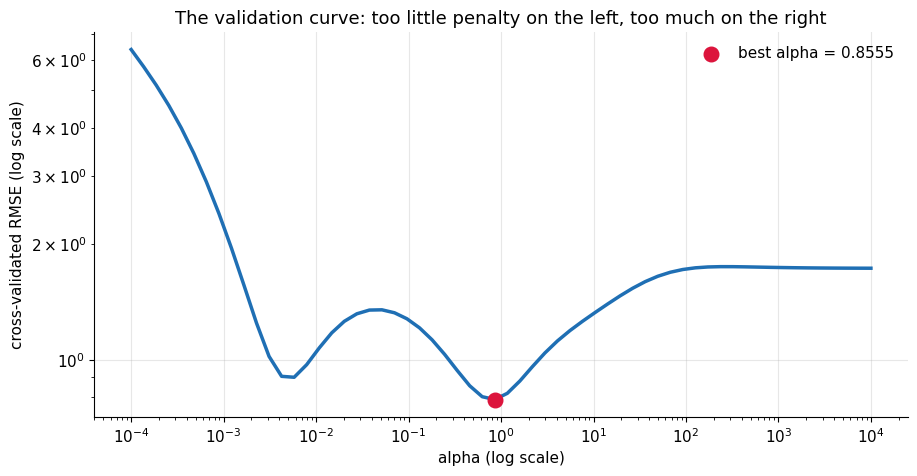

Chosen alpha              : 0.855467
Cross-validated RMSE there: 0.7881

Note: this used ONLY X_train. The test set has still not been touched.


In [80]:
search_alphas = np.logspace(-4, 4, 60)
folds = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_rmse = []

for a in search_alphas:
    pipe = poly_model(Ridge(alpha=a), degree=12)
    # cross_val_score returns NEGATIVE MSE (sklearn always maximises), so we flip the sign
    neg_mse = cross_val_score(pipe, X_train, y_train, cv=folds,
                              scoring="neg_mean_squared_error")
    cv_rmse.append(np.sqrt(-neg_mse.mean()))

cv_rmse = np.array(cv_rmse)
best_idx = int(np.argmin(cv_rmse))
best_alpha = search_alphas[best_idx]

plt.figure(figsize=(10.5, 5))
plt.plot(search_alphas, cv_rmse, color=C_RIDGE, linewidth=2.5)
plt.scatter([best_alpha], [cv_rmse[best_idx]], color="crimson", s=110, zorder=5,
            label=f"best alpha = {best_alpha:.4g}")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("cross-validated RMSE (log scale)")
plt.title("The validation curve: too little penalty on the left, too much on the right")
plt.legend()
plt.show()

print(f"Chosen alpha              : {best_alpha:.6g}")
print(f"Cross-validated RMSE there: {cv_rmse[best_idx]:.4f}")
print("\nNote: this used ONLY X_train. The test set has still not been touched.")

> **CHECKPOINT — the U-shape is the whole story**
>
> The curve is high on the left (**overfitting** — penalty too weak), dips to a minimum in the
> middle (**the sweet spot**), and climbs again on the right (**underfitting** — penalty too strong).
>
> You will meet this U-shaped curve for almost every hyperparameter in machine learning.
> Recognising it is a genuinely transferable skill.

## 6.4 The shortcut: `GridSearchCV`

You will not write that loop by hand every time. `GridSearchCV` is the same loop, packaged:
give it a model, a list of values to try, and a CV scheme, and it returns the winner.

In [81]:
# The same search as above, in three lines.
# "model__alpha" means: the parameter called `alpha`, inside the pipeline step called "model".
search = GridSearchCV(
    poly_model(Ridge(), degree=12),
    param_grid={"model__alpha": search_alphas},
    cv=folds,
    scoring="neg_mean_squared_error",
)
search.fit(X_train, y_train)

print("Alpha chosen by GridSearchCV :", round(search.best_params_["model__alpha"], 6))
print("Alpha we found by hand       :", round(best_alpha, 6))
print("\nIdentical -- GridSearchCV is just the loop above, written for you.")

print("\nNOW, and only now, we look at the test set:")
for k, v in scores(y_test, search.predict(X_test)).items():
    print(f"   {k:<5}: {v:.4f}")

print("\nCompare that to the degree-12 model with NO regularization from Part 1:")
print(f"   R2   : {r2_score(y_test, fitted[12].predict(X_test)):,.1f}")

Alpha chosen by GridSearchCV : 0.855467
Alpha we found by hand       : 0.855467

Identical -- GridSearchCV is just the loop above, written for you.

NOW, and only now, we look at the test set:
   MAE  : 1.0761
   RMSE : 1.1626
   R2   : 0.7896

Compare that to the degree-12 model with NO regularization from Part 1:
   R2   : -2,682,634.1


> **THE GOLDEN RULE OF HYPERPARAMETER TUNING**
>
> 1. Split off the test set and **put it away**.
> 2. Use cross-validation **on the training set** to choose `alpha`.
> 3. Refit on the full training set with the chosen `alpha`.
> 4. Evaluate on the test set **once**.
> 5. Report that number. Do not go back and re-tune. If you do, you need a fresh test set.

**A faster alternative:** scikit-learn also ships `RidgeCV` and `LassoCV`, which do the same
search using algorithms specialised for these two models, so they run much faster on big data.
We use them in Part 7. `GridSearchCV` is the general-purpose tool and works for any model and
any hyperparameter, which is why it is worth learning first.

---
# Part 7 — A real dataset, end to end

Everything so far used a toy dataset that we built ourselves. Now let's do the whole
workflow properly on real data.

**California Housing**: 20,640 real districts in California. Eight features describing each
district. The target is the median house value in that district, in units of $100,000
(so `2.5` means $250,000).

In [82]:
df = pd.read_csv("/content/sample_data/california_housing_train.csv")
X_ca = df.drop("median_house_value", axis=1)
y_ca = df["median_house_value"]
print(f"Rows     : {X_ca.shape[0]:,}")
print(f"Features : {X_ca.shape[1]}")




Rows     : 17,000
Features : 8


In [83]:
# Look at the ranges -- this is exactly why scaling matters
summary = X_ca.describe().T[["mean", "std", "min", "max"]]
display(summary.round(2))

print("Population runs into the tens of thousands, while AveBedrms is close to 1.")
print("Without scaling, the penalty would treat these two wildly differently.")

,mean,std,min,max
longitude,-119.56,2.01,-124.35,-114.31
latitude,35.63,2.14,32.54,41.95
housing_median_age,28.59,12.59,1.00,52.00
total_rooms,2643.66,2179.95,2.00,37937.00
total_bedrooms,539.41,421.50,1.00,6445.00
population,1429.57,1147.85,3.00,35682.00
households,501.22,384.52,1.00,6082.00
median_income,3.88,1.91,0.50,15.00


Population runs into the tens of thousands, while AveBedrms is close to 1.
Without scaling, the penalty would treat these two wildly differently.


## 7.1 Split, then build three models

Same recipe every time:
`Pipeline(scaler + model)` -> cross-validate `alpha` on train -> evaluate once on test.

In [84]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_ca, y_ca, test_size=0.20, random_state=RANDOM_STATE
)
print(f"Training rows: {len(X_tr):,}")
print(f"Test rows    : {len(X_te):,}   <-- locked away until the very end")

Training rows: 13,600
Test rows    : 3,400   <-- locked away until the very end


In [85]:
# 1. Baseline: plain Linear Regression (no penalty). Our reference point.
lin_ca = Pipeline([("scaler", StandardScaler()),
                   ("model",  LinearRegression())]).fit(X_tr, y_tr)

# 2. Ridge, with alpha chosen by 5-fold CV on the training set
ridge_ca = Pipeline([("scaler", StandardScaler()),
                     ("model",  RidgeCV(alphas=np.logspace(-4, 4, 80), cv=5))]).fit(X_tr, y_tr)

# 3. Lasso, same treatment
lasso_ca = Pipeline([("scaler", StandardScaler()),
                     ("model",  LassoCV(alphas=np.logspace(-5, 1, 80), cv=5,
                                        max_iter=50000, random_state=RANDOM_STATE))]).fit(X_tr, y_tr)

print("Alpha chosen for Ridge :", round(ridge_ca.named_steps["model"].alpha_, 6))
print("Alpha chosen for Lasso :", round(lasso_ca.named_steps["model"].alpha_, 6))

Alpha chosen for Ridge : 23.285663
Alpha chosen for Lasso : 10.0


In [86]:
results_ca = pd.DataFrame([
    {"Model": "Linear Regression", **scores(y_te, lin_ca.predict(X_te))},
    {"Model": "Ridge (CV-tuned)",  **scores(y_te, ridge_ca.predict(X_te))},
    {"Model": "Lasso (CV-tuned)",  **scores(y_te, lasso_ca.predict(X_te))},
])
results_ca["Features used"] = [
    X_ca.shape[1],
    X_ca.shape[1],
    int(np.count_nonzero(lasso_ca.named_steps["model"].coef_)),
]
display(results_ca.set_index("Model").round(4))

,MAE,RMSE,R2,Features used
Model,,,,
Linear Regression,49983.4747,68078.3255,0.6636,8
Ridge (CV-tuned),49993.1161,68101.8211,0.6634,8
Lasso (CV-tuned),49986.0040,68080.8627,0.6636,8


,Linear,Ridge,Lasso
longitude,-87098.434,-84794.551,-86990.699
latitude,-91983.102,-89698.881,-91878.693
housing_median_age,14256.838,14466.902,14262.682
total_rooms,-19175.064,-18520.907,-18995.174
total_bedrooms,47893.657,45414.304,47709.118
population,-41374.291,-41112.599,-41312.027
households,17328.745,18986.885,17281.343
median_income,76754.043,76690.194,76717.527


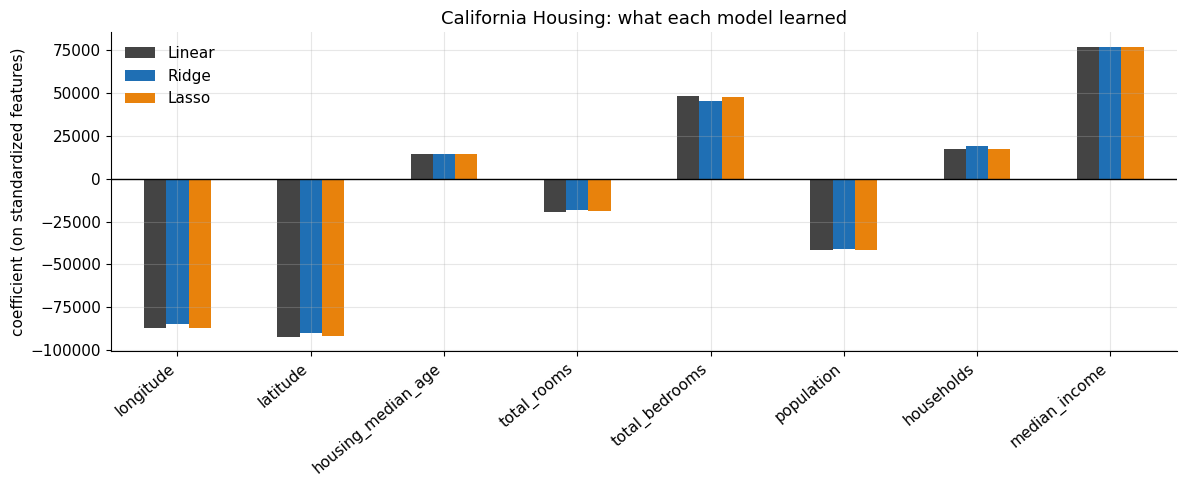

Because the features were standardized, these bars ARE comparable to each other.
MedInc (median income) is by far the strongest predictor of house value. Sensible.


In [87]:
# Compare the coefficients the three models learned
coefs_ca = pd.DataFrame({
    "Linear": lin_ca.named_steps["model"].coef_,
    "Ridge":  ridge_ca.named_steps["model"].coef_,
    "Lasso":  lasso_ca.named_steps["model"].coef_,
}, index=X_ca.columns)

display(coefs_ca.round(3))

coefs_ca.plot(kind="bar", figsize=(12, 5),
              color=[C_OLS, C_RIDGE, C_LASSO])
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("coefficient (on standardized features)")
plt.title("California Housing: what each model learned")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("Because the features were standardized, these bars ARE comparable to each other.")
print("MedInc (median income) is by far the strongest predictor of house value. Sensible.")

> **CHECKPOINT — and an honest surprise**
>
> All three models score almost identically. Ridge and Lasso barely beat Linear Regression,
> and Lasso may even be slightly worse.
>
> **This is not a bug, and it is not a disappointing result. It is the lesson.**
>
> Regularization fixes overfitting. This problem does not have an overfitting problem:
> 16,512 training rows and only 8 features. There is far more data than there are knobs to turn,
> so plain Linear Regression was never in danger of memorising anything. Adding a penalty to a
> model that wasn't overfitting gives you nothing — you just pay the bias cost for no benefit.
>
> Notice also that cross-validation picked a **small** alpha. The tuning process worked it out
> for itself: "this problem doesn't need much help."
>
> $$\boxed{\text{No overfitting} \;\Rightarrow\; \text{regularization has nothing to fix}}$$
>
> If your exam or interview asks *"does Ridge always beat Linear Regression?"* — the answer is
> **no**, and this table is your evidence.

## 7.2 The rematch — make the problem hard, and watch regularization earn its keep

So when *does* it help? Recreate the conditions from Part 1: **many features, not much data**.

Two changes to the exact same dataset:

1. Train on only **400 rows** instead of 16,512.
2. Expand the 8 features into **all polynomial combinations up to degree 3** —
   squares, cubes, and every interaction like `MedInc x Latitude x HouseAge`.

That turns 8 features into 164. With 400 rows and 164 features, plain Linear Regression has
more than enough freedom to memorise the noise. Exactly the trap from Part 1, on real data.

In [88]:
X_small = X_tr.iloc[:400]
y_small = y_tr.iloc[:400]

n_expanded = PolynomialFeatures(degree=3, include_bias=False).fit(X_small).n_output_features_
print(f"Training rows            : {len(X_small)}")
print(f"Features after expansion : {n_expanded}")
print(f"Rows per feature         : {len(X_small) / n_expanded:.1f}   <-- dangerously low")

def hard_model(model):
    return Pipeline([
        ("poly",   PolynomialFeatures(degree=3, include_bias=False)),
        ("scaler", StandardScaler()),
        ("model",  model),
    ])

hard_lin   = hard_model(LinearRegression()).fit(X_small, y_small)
hard_ridge = hard_model(RidgeCV(alphas=np.logspace(-3, 5, 80), cv=5)).fit(X_small, y_small)
hard_lasso = hard_model(LassoCV(alphas=np.logspace(-4, 1, 80), cv=5,
                                max_iter=50000, random_state=RANDOM_STATE)).fit(X_small, y_small)

results_hard = pd.DataFrame([
    {"Model": "Linear Regression", **scores(y_te, hard_lin.predict(X_te))},
    {"Model": "Ridge (CV-tuned)",  **scores(y_te, hard_ridge.predict(X_te))},
    {"Model": "Lasso (CV-tuned)",  **scores(y_te, hard_lasso.predict(X_te))},
])
results_hard["Features used"] = [
    n_expanded,
    n_expanded,
    int(np.count_nonzero(hard_lasso.named_steps["model"].coef_)),
]
display(results_hard.set_index("Model").round(4))

Training rows            : 400
Features after expansion : 164
Rows per feature         : 2.4   <-- dangerously low


,MAE,RMSE,R2,Features used
Model,,,,
Linear Regression,126634.4458,621283.4663,-27.0135,164
Ridge (CV-tuned),52794.2025,100827.4088,0.2622,164
Lasso (CV-tuned),70056.0862,315301.2623,-6.2150,89


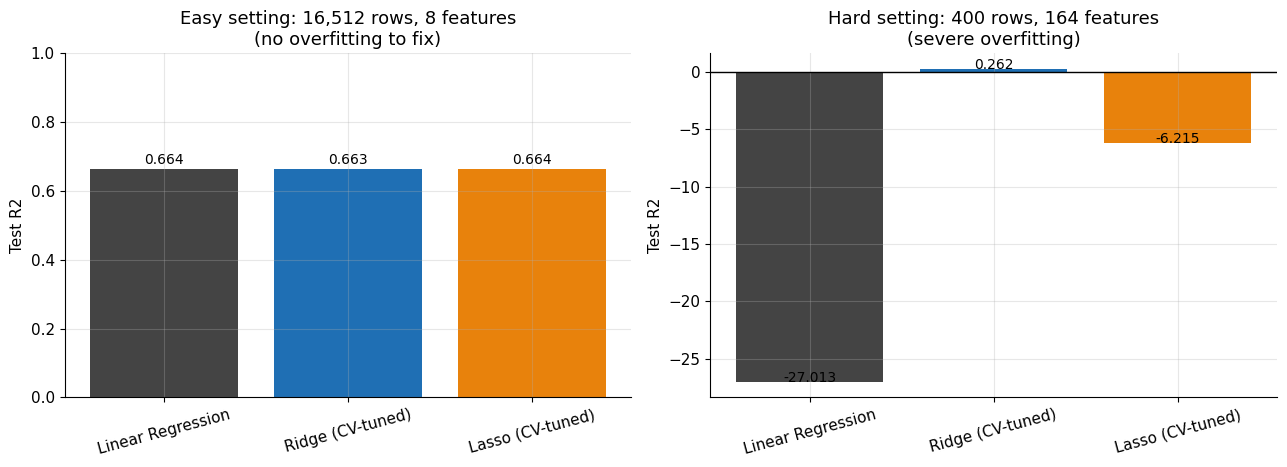

In [89]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
bar_colors = [C_OLS, C_RIDGE, C_LASSO]

axes[0].bar(results_ca["Model"], results_ca["R2"], color=bar_colors)
axes[0].set_title("Easy setting: 16,512 rows, 8 features\n(no overfitting to fix)")
axes[0].set_ylabel("Test R2")
axes[0].set_ylim(0, 1)

axes[1].bar(results_hard["Model"], results_hard["R2"], color=bar_colors)
axes[1].set_title(f"Hard setting: 400 rows, {n_expanded} features\n(severe overfitting)")
axes[1].set_ylabel("Test R2")
axes[1].axhline(0, color="black", linewidth=1)

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(ax.containers[0].datavalues):
        ax.text(i, v + 0.02 * abs(max(ax.containers[0].datavalues)), f"{v:.3f}",
                ha="center", fontsize=10)

plt.tight_layout()
plt.show()

> **CHECKPOINT — the payoff**
>
> In the hard setting the gap is large. Linear Regression's test R2 falls off a cliff
> (depending on your run it may even go negative, meaning it is worse than just predicting
> the average), while Ridge and Lasso stay respectable. Lasso does it while throwing away most of the
> 164 features — it found the handful that actually carry signal.
>
> Put the two panels together and you have the complete answer to *"when should I regularize?"*:

| Situation | Does regularization help? |
|---|---|
| Lots of rows, few features, no overfitting | Barely. Alpha will be tuned small anyway. |
| Few rows, many features | **Enormously.** This is what it is for. |
| Highly correlated features | Yes — Ridge stabilises the coefficients |
| You want a short, readable model | Yes — use Lasso for the feature selection |
| Features are on wildly different scales | Scale them first, then it helps |

> **Rule of thumb:** the more features you have relative to rows, the more you need this.

---
# Part 8 — Reference section

Everything worth remembering, in one place. Come back here later.

## 8.1 The cheat sheet

**The three loss functions:**

$$\text{Linear Regression:}\quad \mathrm{MSE}$$

$$\text{Ridge:}\quad \mathrm{MSE} + \alpha \sum_{j=1}^{p} \beta_j^{2}$$

$$\text{Lasso:}\quad \mathrm{MSE} + \alpha \sum_{j=1}^{p} \lvert \beta_j \rvert$$

**The code you will actually write:**

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, LassoCV
import numpy as np

# Ridge
model = Pipeline([
    ("scaler", StandardScaler()),
    ("model",  RidgeCV(alphas=np.logspace(-4, 4, 100), cv=5)),
])
model.fit(X_train, y_train)

print("chosen alpha:", model.named_steps["model"].alpha_)
print("coefficients:", model.named_steps["model"].coef_)

# Lasso: swap in LassoCV(alphas=np.logspace(-5, 1, 100), cv=5, max_iter=50000)
```

**Six facts to remember:**

1. `alpha = 0` is exactly plain Linear Regression.
2. Bigger `alpha` = smaller coefficients = simpler model. Not "better".
3. Ridge shrinks everything; Lasso shrinks and deletes.
4. Always scale first, inside a `Pipeline`.
5. Choose `alpha` by cross-validation on the training set.
6. The test set is used once, at the end.

## 8.2 Which one should I use?

```
Is your model overfitting?
(big gap between train score and test score)
 |
 +-- NO  --> You probably don't need regularization.
 |           A small alpha chosen by CV will do no harm, so it is a safe default anyway.
 |
 +-- YES --> Do you have many features, and do you suspect most are useless?
             |
             +-- YES --> LASSO. It will delete them for you and give a short,
             |           readable model.
             |
             +-- NO / not sure --> RIDGE. Safer default. Keeps every feature,
                         |         handles correlated features gracefully,
                         |         and always has a solution.
                         |
                         +-- Want both behaviours? --> ELASTIC NET
                                                       (sklearn.linear_model.ElasticNet)
```

**If you are unsure, start with Ridge.** It is the safer of the two and rarely does harm.

## 8.3 Ten mistakes to avoid

| # | Mistake | Why it hurts |
|---|---|---|
| 1 | Not scaling features before Ridge/Lasso | The penalty becomes unfair; see Part 5 |
| 2 | Scaling **before** the train/test split | Data leakage; your test score is a lie |
| 3 | Picking `alpha` by best test score | You have burned your test set |
| 4 | Assuming bigger `alpha` is better | It means more constrained, not better |
| 5 | Expecting Ridge to produce exact zeros | It never does; that is Lasso's job |
| 6 | Expecting Ridge/Lasso to always beat Linear Regression | Part 7.1 shows a real case where they don't |
| 7 | Reading a Lasso zero as "this feature is unimportant" | With correlated features it may just be redundant |
| 8 | Treating `alpha` as something the model learns | It is a hyperparameter; **you** choose it |
| 9 | Comparing raw coefficients across unscaled features | Their sizes depend on the units |
| 10 | Forgetting `max_iter` on Lasso with many features | It may stop before converging and warn you |

## 8.4 Glossary

| Term | Meaning |
|---|---|
| **Coefficient** ($\beta$) | The weight the model multiplies a feature by. Learned from data. |
| **Intercept** ($\beta_0$) | The baseline prediction when all features are 0. Never penalised. |
| **Overfitting** | The model memorised the training data, including the noise. Great train score, poor test score. |
| **Underfitting** | The model is too rigid to capture the real pattern. Poor on both train and test. |
| **Bias** | Error from the model being too simple to represent the truth. |
| **Variance** | Error from the model being too sensitive to which particular rows it was trained on. |
| **Bias-variance trade-off** | Reducing one usually increases the other. Regularization trades a little bias for a lot less variance. |
| **Regularization** | Adding a penalty on coefficient size to the loss function. |
| **L2 penalty** | $\sum \beta_j^2$. Used by Ridge. |
| **L1 penalty** | $\sum \lvert\beta_j\rvert$. Used by Lasso. |
| **Alpha** ($\alpha$) | Regularization strength. Chosen by you, usually via cross-validation. |
| **Hyperparameter** | Any setting chosen before training rather than learned from the data. |
| **Shrinkage** | Pulling coefficients toward zero. |
| **Feature selection** | Removing features entirely. Lasso does this; Ridge does not. |
| **Sparse model** | A model where most coefficients are exactly zero. |
| **Standardization** | Rescaling a feature to mean 0, standard deviation 1. |
| **Data leakage** | Information from the test set influencing training. Produces optimistic, fake scores. |
| **Cross-validation** | Rotating which slice of the training data is held out, then averaging the scores. |
| **Regularization path** | A plot of how every coefficient changes as `alpha` sweeps across a range. |
| **Elastic Net** | A model using both L1 and L2 penalties together. |

---
# Part 9 — Practice

Try each one before opening the solution. Clicking straight to the answer teaches you nothing.

### Exercise 1 — Prove that `alpha = 0` is Linear Regression

Fit `Ridge(alpha=0)` and `LinearRegression()` on the same data and show that their
coefficients are (nearly) identical.

In [90]:
# YOUR CODE HERE
# Hint: use X_tr, y_tr from Part 7 and wrap both in a Pipeline with StandardScaler.

<details>
<summary><b>Show solution</b></summary>

```python
a = Pipeline([("s", StandardScaler()), ("m", LinearRegression())]).fit(X_tr, y_tr)
b = Pipeline([("s", StandardScaler()), ("m", Ridge(alpha=0))]).fit(X_tr, y_tr)

print("Linear Regression:", np.round(a.named_steps["m"].coef_, 6))
print("Ridge(alpha=0)   :", np.round(b.named_steps["m"].coef_, 6))
print("Largest difference:", np.abs(a.named_steps["m"].coef_ - b.named_steps["m"].coef_).max())
```

The largest difference is around 1e-10 — that is floating-point rounding, not a real difference.
They are the same model. Ridge with no penalty **is** ordinary least squares.

</details>

### Exercise 2 — Find the alpha at which Lasso deletes everything

Increase `alpha` for Lasso on the California Housing training data until **every** coefficient
is zero. Roughly where does that happen, and what does the model predict at that point?

In [91]:
# YOUR CODE HERE
# Hint: loop over np.logspace(-3, 1, 40) and count np.count_nonzero(coef_) each time.

<details>
<summary><b>Show solution</b></summary>

```python
for a in np.logspace(-3, 1, 40):
    m = Pipeline([("s", StandardScaler()),
                  ("m", Lasso(alpha=a, max_iter=50000))]).fit(X_tr, y_tr)
    k = np.count_nonzero(m.named_steps["m"].coef_)
    print(f"alpha = {a:>10.4f}   non-zero features = {k}")
    if k == 0:
        print("\nEverything deleted. The model now predicts the same number for every row:")
        print("  prediction :", round(m.predict(X_te)[0], 4))
        print("  train mean :", round(y_tr.mean(), 4))
        break
```

Once every coefficient is zero, only the intercept survives — so the model predicts the
**mean of the training target** for every single row. Its R2 on the test set will be
approximately 0, which is the definition of "no better than guessing the average".
This is underfitting in its purest possible form.

</details>

### Exercise 3 — Does Ridge make the model more stable?

Fit the degree-12 model from Part 1 on **two different random train/test splits**
(`random_state=1` and `random_state=2`), once with `LinearRegression` and once with
`Ridge(alpha=1)`. Compare how much the coefficients move between the two splits.

In [92]:
# YOUR CODE HERE
# Hint: loop over random_state in [1, 2], collect .named_steps["model"].coef_,
# then compare the two coefficient vectors for each method.

<details>
<summary><b>Show solution</b></summary>

```python
for label, mk in [("Linear Regression", lambda: LinearRegression()),
                  ("Ridge (alpha=1)   ", lambda: Ridge(alpha=1.0))]:
    cs = []
    for rs in [1, 2]:
        Xa, _, ya, _ = train_test_split(X, y, test_size=0.30, random_state=rs)
        m = poly_model(mk(), degree=12).fit(Xa, ya)
        cs.append(m.named_steps["model"].coef_)
    move = np.abs(cs[0] - cs[1]).max()
    print(f"{label}  largest coefficient change between splits: {move:,.2f}")
```

Linear Regression's coefficients swing by **thousands** when you merely reshuffle which rows
landed in the training set. Ridge's move by about a tenth of a unit.

That instability **is** variance. A model whose answer changes dramatically depending on which
rows happened to land in the training set cannot be trusted on new rows. Regularization is,
at bottom, a device for buying stability.

</details>

---
## 9.1 Quick quiz

Answer all eight before scrolling. Write them down.

1. If `alpha = 0`, what model do Ridge and Lasso become?
2. Which of the two can set a coefficient to exactly zero, and what does the other one do instead?
3. Why does Lasso's penalty allow exact zeros when Ridge's does not?
4. Why must features be scaled before Ridge or Lasso, but not before plain Linear Regression?
5. What goes wrong if you call `StandardScaler().fit_transform(X)` before `train_test_split`?
6. You test 50 values of `alpha` and report the best test R2. What is wrong with that number?
7. Ridge gives a lower test R2 than Linear Regression on your dataset. Is Ridge broken?
8. Your dataset has 60 rows and 900 features. Which do you reach for first, and why?

<details>
<summary><b>Show answer key</b></summary>

1. **Ordinary Linear Regression.** The penalty term is multiplied by zero and disappears.

2. **Lasso** produces exact zeros. **Ridge** shrinks coefficients toward zero but never all
   the way, so every feature stays in the model.

3. The pull toward zero from the L2 penalty is $2\beta$, which **fades away** as $\beta$
   approaches zero — so the coefficient converges toward zero without arriving. The pull from
   the L1 penalty is a **constant** $\pm 1$ regardless of how small $\beta$ is, so it can push
   a coefficient onto exactly zero and hold it there.

4. Because the penalty is applied to coefficient **size**, and coefficient size depends on the
   feature's units. A feature measured in tiny units needs a huge coefficient, which the penalty
   then punishes for no good reason. Plain Linear Regression has no penalty, so units are
   irrelevant to it.

5. **Data leakage.** The scaler's mean and standard deviation would be computed using the test
   rows, so information from the test set reaches the model during training. The resulting test
   score is optimistically biased and does not represent performance on new data.

6. It is **optimistically biased**. By choosing the alpha that best fits that particular test
   set, you have effectively tuned on it — it is now a validation set, not an unbiased estimate
   of generalization. The honest approach is cross-validation on the training set.

7. **No.** Regularization deliberately adds bias to reduce variance. If the model was not
   overfitting in the first place, there is no variance to remove, so you pay the bias cost for
   no benefit. Part 7.1 demonstrates precisely this on real data.

8. With 900 features and only 60 rows, plain Linear Regression will overfit catastrophically —
   it has far more knobs than data points. Reach for **Lasso**: most of those 900 features are
   almost certainly noise, and Lasso will delete them and hand you a short, interpretable model.
   **Ridge** is a reasonable alternative if you believe many features each contribute a little.
   Either way, cross-validate `alpha`.

</details>

---
# Final takeaway

### The one-line version

> Plain Linear Regression is told *"minimise training error, by any means necessary."*
> Regularization adds *"...and keep your coefficients small while you do it."*

### The two methods

$$\text{Ridge}\;=\; \mathrm{MSE} + \alpha \sum \beta_j^{2} \qquad\longrightarrow\qquad \textbf{shrinks every coefficient}$$

$$\text{Lasso}\;=\; \mathrm{MSE} + \alpha \sum \lvert\beta_j\rvert \qquad\longrightarrow\qquad \textbf{shrinks, and deletes some entirely}$$

### The workflow, every time

$$\text{split} \;\rightarrow\; \text{Pipeline(scale + model)} \;\rightarrow\; \text{CV-tune } \alpha \text{ on train} \;\rightarrow\; \text{fit} \;\rightarrow\; \text{test once}$$

### The thing most people get wrong

Regularization is **not** a switch that makes scores go up. It is a **trade**:
you give up some ability to fit the training data in exchange for a model that is
more stable and generalises better. On a problem that was never overfitting,
that trade buys you nothing — and cross-validation will tell you so by picking a small `alpha`.

Use it when you have many features relative to rows, when features are correlated,
or when you want a short model. Tune it honestly. Report the test score once.

---

*Suggested next steps: `ElasticNet` (both penalties at once), `GridSearchCV` (tuning several
hyperparameters together), and logistic regression with the same L1/L2 penalties for
classification problems.*